 Данные успешно загружены. Записей: 1000

--- Анализ Линейной Регрессии ---


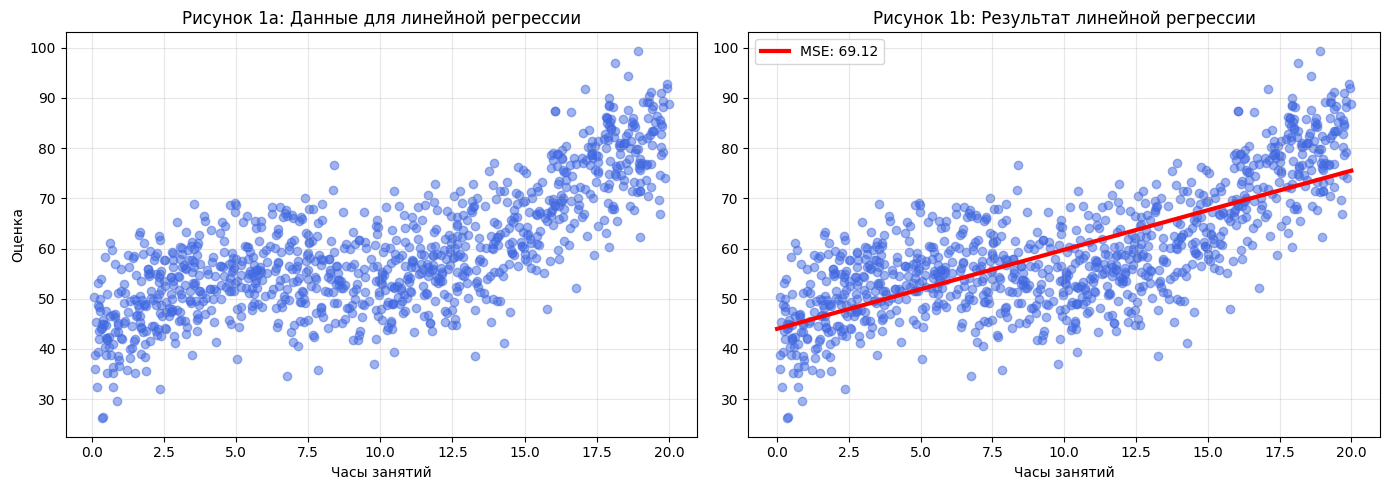


--- Анализ Полиномиальной Регрессии ---


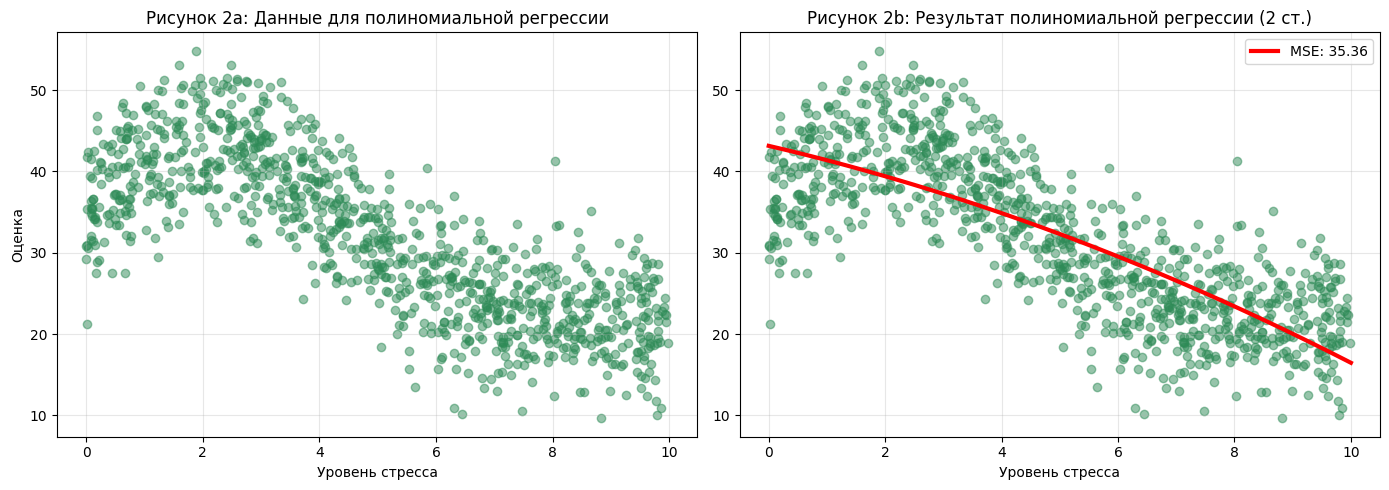


--- Анализ Нейронной Сети ---


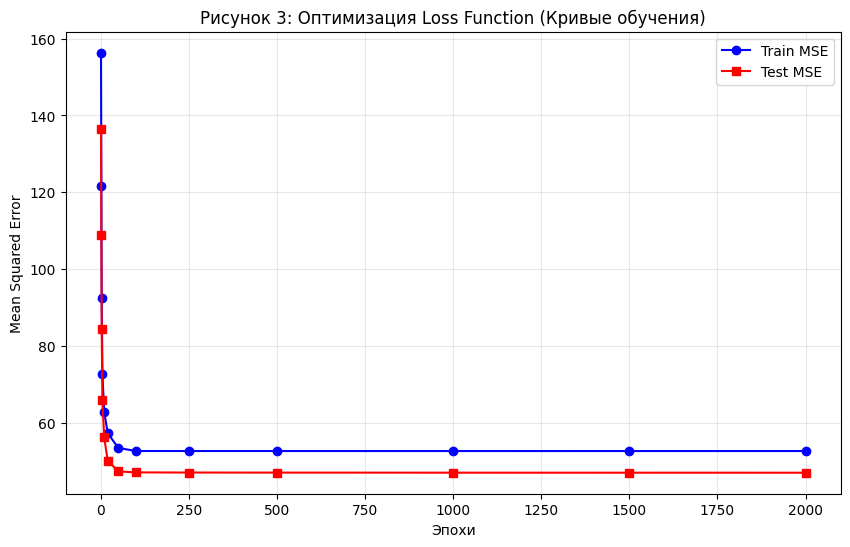


СРАВНЕНИЕ ФУНКЦИЙ ПОТЕРЬ (MSE)
1. Линейная регрессия: 69.1221
2. Полином (2 степень): 35.3643
3. Нейронная сеть:      46.9410
--------------------------------------------------
 Лучшая модель: Полином с MSE = 35.3643


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
import pandas as pd
import os
import warnings


warnings.filterwarnings("ignore")


def load_data(filename='student_performance.csv'):
    if not os.path.exists(filename):
        print(f" Ошибка: Файл '{filename}' не найден!")
        return None
    data = pd.read_csv(filename)
    print(f" Данные успешно загружены. Записей: {len(data)}")
    return data


def plot_linear_analysis(data):
    X = data['hours_studied'].values.reshape(-1, 1)
    y = data['exam_score_linear'].values
    
    model = LinearRegression().fit(X, y)
    X_pred = np.linspace(0, 20, 100).reshape(-1, 1)
    y_pred = model.predict(X_pred)
    mse = mean_squared_error(y, model.predict(X))

    plt.figure(figsize=(14, 5))

   
    plt.subplot(1, 2, 1)
    plt.scatter(X, y, alpha=0.5, color='royalblue', label='Студенты')
    plt.title("Рисунок 1a: Данные для линейной регрессии")
    plt.xlabel("Часы занятий")
    plt.ylabel("Оценка")
    plt.grid(True, alpha=0.3)


    plt.subplot(1, 2, 2)
    plt.scatter(X, y, alpha=0.5, color='royalblue')
    plt.plot(X_pred, y_pred, color='red', linewidth=3, label=f'MSE: {mse:.2f}')
    plt.title("Рисунок 1b: Результат линейной регрессии")
    plt.xlabel("Часы занятий")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return mse

def plot_poly_analysis(data, degree=2):
    X = data['stress_level'].values.reshape(-1, 1)
    y = data['exam_score_poly'].values
    
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(X, y)
    X_pred = np.linspace(0, 10, 100).reshape(-1, 1)
    y_pred = model.predict(X_pred)
    mse = mean_squared_error(y, model.predict(X))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(X, y, alpha=0.5, color='seagreen', label='Студенты')
    plt.title("Рисунок 2a: Данные для полиномиальной регрессии")
    plt.xlabel("Уровень стресса")
    plt.ylabel("Оценка")
    plt.grid(True, alpha=0.3)

    
    plt.subplot(1, 2, 2)
    plt.scatter(X, y, alpha=0.5, color='seagreen')
    plt.plot(X_pred, y_pred, color='red', linewidth=3, label=f'MSE: {mse:.2f}')
    plt.title(f"Рисунок 2b: Результат полиномиальной регрессии ({degree} ст.)")
    plt.xlabel("Уровень стресса")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return mse

def plot_neural_network_learning_curves(data, max_epochs=2000):
    X = data['hours_studied'].values.reshape(-1, 1)
    y = data['exam_score_linear'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler_x, scaler_y = StandardScaler(), StandardScaler()
    X_train_s = scaler_x.fit_transform(X_train)
    X_test_s = scaler_x.transform(X_test)
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test_s = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

    epochs_range = [1, 2, 3, 5, 10, 20, 50, 100, 250, 500, 1000, 1500, max_epochs]
    train_losses, test_losses = [], []

    nn = MLPRegressor(
        hidden_layer_sizes=(50, 25), 
        activation='relu', 
        solver='sgd', 
        learning_rate_init=0.005, 
        momentum=0.9,
        random_state=42, 
        warm_start=True
    )


    for epoch in epochs_range:
        nn.set_params(max_iter=epoch)
        nn.fit(X_train_s, y_train_s)
        
        p_train = scaler_y.inverse_transform(nn.predict(X_train_s).reshape(-1, 1))
        p_test = scaler_y.inverse_transform(nn.predict(X_test_s).reshape(-1, 1))
        
        train_losses.append(mean_squared_error(y_train, p_train))
        test_losses.append(mean_squared_error(y_test, p_test))

    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, train_losses, 'b-o', label='Train MSE')
    plt.plot(epochs_range, test_losses, 'r-s', label='Test MSE')
    plt.title('Рисунок 3: Оптимизация Loss Function (Кривые обучения)')
    plt.xlabel('Эпохи')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return test_losses[-1]


def main():
    filename = 'student_performance.csv'
    data = load_data(filename)
    
    if data is not None:
        print("\n--- Анализ Линейной Регрессии ---")
        mse_lin = plot_linear_analysis(data)
        
        print("\n--- Анализ Полиномиальной Регрессии ---")
        mse_poly = plot_poly_analysis(data, degree=2)
        
        print("\n--- Анализ Нейронной Сети ---")
        mse_nn = plot_neural_network_learning_curves(data)
        

        print("\n" + "="*50)
        print("СРАВНЕНИЕ ФУНКЦИЙ ПОТЕРЬ (MSE)")
        print("="*50)
        print(f"1. Линейная регрессия: {mse_lin:.4f}")
        print(f"2. Полином (2 степень): {mse_poly:.4f}")
        print(f"3. Нейронная сеть:      {mse_nn:.4f}")
        print("-" * 50)
        
        best_model = min([("Линейная", mse_lin), ("Полином", mse_poly), ("Нейросеть", mse_nn)], key=lambda x: x[1])
        print(f" Лучшая модель: {best_model[0]} с MSE = {best_model[1]:.4f}")
        print("="*50)

if __name__ == "__main__":
    main()